## 3. Anwendung auf den California-Housing-Datensatz

In [18]:
import random  
import numpy as np                              
import matplotlib.pyplot as plt
from sklearn.linear_model import (
    LinearRegression,                           
    HuberRegressor,   
)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [8]:
# Datensatz laden
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Feature-Matrix:", X.shape)
print("Zielvariable:", y.shape)
display(X.head())
display(y.head())

Feature-Matrix: (20640, 8)
Zielvariable: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [9]:
# Train-Test- Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (16512, 8) (16512,)
Test : (4128, 8) (4128,)


### 3.1 Training ohne Skalierung

In [10]:
reg_housing = LinearRegression()
reg_housing.fit(X_train, y_train)

y_pred = reg_housing.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

MSE : 0.5559
RMSE: 0.7456
MAE : 0.5332
R^2 : 0.5758


/opt/conda/envs/learn-ai-1/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [11]:
# Koeffizienten übersichtlich darstellen
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Koeffizient": reg_housing.coef_
}).sort_values("Koeffizient", key=np.abs, ascending=False)

coef_table

,Feature,Koeffizient
3,AveBedrms,0.783145
0,MedInc,0.448675
7,Longitude,-0.433708
6,Latitude,-0.419792
2,AveRooms,-0.123323
1,HouseAge,0.009724
5,AveOccup,-0.003526
4,Population,-0.000002


In [12]:
print("Intercept / Bias:", reg_housing.intercept_)

Intercept / Bias: -37.02327770606409


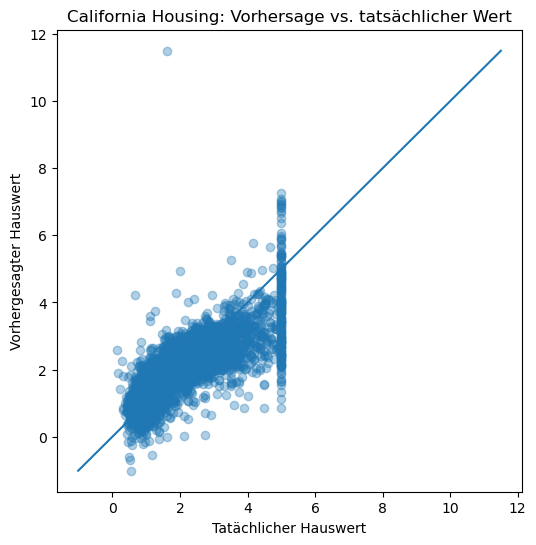

In [17]:
# Vorhersage vs. Wahrheit
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.35)
plt.xlabel("Tatächlicher Hauswert")
plt.ylabel("Vorhergesagter Hauswert")
plt.title("California Housing: Vorhersage vs. tatsächlicher Wert")

min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.show()

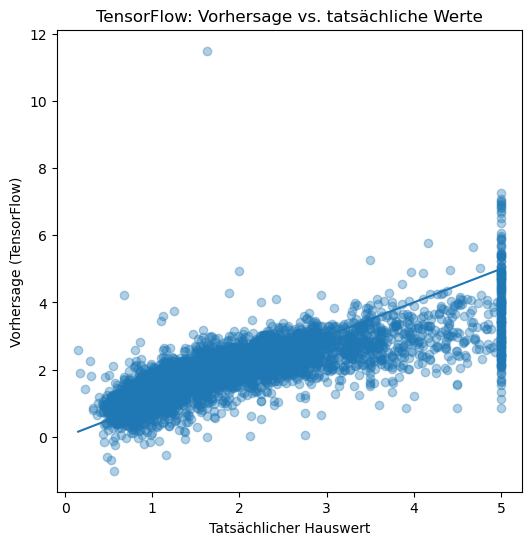

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.35)
plt.xlabel("Tatsächlicher Hauswert")
plt.ylabel("Vorhersage (TensorFlow)")
plt.title("TensorFlow: Vorhersage vs. tatsächliche Werte")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()